# Pairs Trading Strategy — Cointegration, Mean Reversion & OU Model

A self-contained, runnable implementation of a statistical-arbitrage pairs trading strategy:

1. Cointegration testing (Engle-Granger + ADF) and hedge ratio estimation
2. Spread construction and z-score signal generation
3. Ornstein-Uhlenbeck model fit as an alternative spread model
4. Walk-forward backtest with realistic risk controls (max holding period, stop-loss, cointegration-breakdown exit, transaction costs)
5. Performance metrics (total return, win rate, Sharpe, max drawdown, trade stats)

**This notebook does not guarantee profit.** It's a research framework — see the Limitations section at the end before using it on real capital.

Companion write-up with full math and pseudocode: `pairs_trading_strategy.md` (same conversation).


## 1. Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import coint, adfuller
import statsmodels.api as sm
from scipy.optimize import minimize
from dataclasses import dataclass, field

np.random.seed(42)
plt.rcParams['figure.figsize'] = (11, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


### 1a. Timeframe / interval metadata

`yfinance` imposes hard history limits on intraday intervals, and FX trades roughly 24h/5days
(vs. equities' single daily session), so "252 bars" means something different at `1d` vs `1h`.
To avoid re-deriving every parameter by hand when switching timeframes, the config below is
specified in **calendar days** (formation window, z-window, max holding period) and
automatically converted into bar counts for whichever `interval` is selected.


In [2]:
# interval -> (max_history_days available via yfinance, approx bars/day for FX ~24h trading, notes)
INTERVAL_INFO = {
    '1m':  {'max_history_days': 7,    'bars_per_day': 1440, 'note': 'Only 7 days of history via yfinance'},
    '2m':  {'max_history_days': 60,   'bars_per_day': 720,  'note': '60 days of history via yfinance'},
    '5m':  {'max_history_days': 60,   'bars_per_day': 288,  'note': '60 days of history via yfinance'},
    '15m': {'max_history_days': 60,   'bars_per_day': 96,   'note': '60 days of history via yfinance'},
    '30m': {'max_history_days': 60,   'bars_per_day': 48,   'note': '60 days of history via yfinance'},
    '60m': {'max_history_days': 730,  'bars_per_day': 24,   'note': '~2 years of history via yfinance'},
    '1h':  {'max_history_days': 730,  'bars_per_day': 24,   'note': 'same as 60m, ~2 years of history'},
    '1d':  {'max_history_days': None, 'bars_per_day': 1,        'note': 'Full history, no limit'},
    '1wk': {'max_history_days': None, 'bars_per_day': 1 / 5,    'note': 'Full history, no limit'},
    '1mo': {'max_history_days': None, 'bars_per_day': 1 / 21,   'note': 'Full history, no limit'},
}

TRADING_DAYS_PER_YEAR = 252   # approximation shared with equities convention


def bars_per_day(interval: str) -> float:
    return INTERVAL_INFO[interval]['bars_per_day']


def check_data_availability(interval: str, start_date: str, end_date: str):
    """Warn if the requested date range exceeds what yfinance will actually return for this interval."""
    max_days = INTERVAL_INFO[interval]['max_history_days']
    requested_days = (pd.Timestamp(end_date) - pd.Timestamp(start_date)).days
    if max_days is not None and requested_days > max_days:
        print(f"WARNING: interval='{interval}' only provides ~{max_days} days of history via "
              f"yfinance, but you requested {requested_days} days ({start_date} to {end_date}). "
              f"The actual download will be silently truncated to the last {max_days} days.")
    else:
        print(f"Data availability OK: interval='{interval}' supports the requested "
              f"{requested_days}-day range. ({INTERVAL_INFO[interval]['note']})")


def recommend_timeframe(half_life_estimate_days: float):
    """Rough decision guide: given a half-life estimated in calendar days (e.g. from a first
    pass on daily data), suggest which interval is likely to be usable, and why."""
    print(f"Estimated half-life: {half_life_estimate_days:.1f} days\n")
    if half_life_estimate_days > 20:
        print("-> Half-life is long (multiple weeks+). Use interval='1d' (or even '1wk').\n"
              "   Intraday bars would need an unrealistically long formation window relative to\n"
              "   yfinance's history limits to see even a handful of full reversion cycles.")
    elif 3 <= half_life_estimate_days <= 20:
        print("-> Half-life is moderate (a few days to a few weeks). interval='1d' is the safest\n"
              "   default (unlimited history). interval='1h' is also workable IF a ~2-year window\n"
              "   is enough to cover ~10-20x the half-life for robust formation/backtesting -\n"
              "   check: 730 days / half_life_days should be comfortably > 10.")
    else:
        print("-> Half-life is short (under a few days). Daily bars will barely capture the\n"
              "   reversion cycle - intraday data (e.g. '1h', '30m', '15m') is more appropriate.\n"
              "   BUT: '30m'/'15m' only offer 60 days of history via yfinance, which limits how\n"
              "   large a formation window and how much out-of-sample data you'll have to work\n"
              "   with - validate carefully and expect noisier cointegration estimates.")
    print("\nRule of thumb: you generally want (available history in days) / (half-life in days)\n"
          "to be at least ~10-15, so the backtest actually observes multiple reversion cycles\n"
          "rather than just a couple of noisy ones.")


In [14]:
@dataclass
class Config:
    # --- Data source ---
    data_source: str = "yfinance"      # "synthetic" or "yfinance"
    ticker_a: str = "EURUSD=X"
    ticker_b: str = "GBPUSD=X"
    interval: str = "4h"               # '1m','5m','15m','30m','1h','1d','1wk','1mo' - see INTERVAL_INFO
    start_date: str = "2018-01-01"
    end_date: str = "2024-01-01"

    # --- Formation / walk-forward (specified in CALENDAR DAYS, auto-converted to bars below) ---
    formation_window_days: float = 252     # history used to estimate gamma + test cointegration
    reform_frequency_days: float = 63      # re-test / re-estimate every N calendar days (~1 quarter)
    z_window_days: float = 30              # rolling window for z-score, in calendar days

    # --- Statistical validation thresholds (in calendar days for readability) ---
    adf_pvalue_max: float = 0.05
    min_half_life_days: float = 3
    max_half_life_days: float = 90

    # --- Trading thresholds ---
    z_entry: float = 2.0
    z_exit: float = 0.5

    # --- Risk controls ---
    max_holding_period_days: float = 60    # in calendar days
    stop_loss_z: float = 3.5               # exit if |z| blows out past this (model-invalidity proxy)
    retest_pvalue_max: float = 0.10        # cointegration re-check threshold while in a trade
    gamma_drift_limit: float = 0.5         # fraction change in hedge ratio that triggers exit

    # --- Costs & sizing ---
    cost_bps_per_leg: float = 1.0          # one-way cost per leg, in bps of notional
    capital_per_trade: float = 100_000.0

    # --- Resolved (bar-count) fields - filled in by resolve_config(), don't set these directly ---
    formation_window: int = field(default=None, init=False)
    reform_frequency: int = field(default=None, init=False)
    z_window: int = field(default=None, init=False)
    max_holding_period: int = field(default=None, init=False)
    min_half_life: float = field(default=None, init=False)
    max_half_life: float = field(default=None, init=False)
    periods_per_year: float = field(default=None, init=False)


def resolve_config(cfg: Config) -> Config:
    """Convert calendar-day parameters into bar counts for the selected interval, and set
    the annualization factor accordingly. Call this any time cfg.interval or a *_days field
    changes."""
    bpd = bars_per_day(cfg.interval)
    cfg.formation_window = max(20, round(cfg.formation_window_days * bpd))
    cfg.reform_frequency = max(5, round(cfg.reform_frequency_days * bpd))
    cfg.z_window = max(5, round(cfg.z_window_days * bpd))
    cfg.max_holding_period = max(1, round(cfg.max_holding_period_days * bpd))
    cfg.min_half_life = max(1, cfg.min_half_life_days * bpd)
    cfg.max_half_life = cfg.max_half_life_days * bpd
    cfg.periods_per_year = bpd * TRADING_DAYS_PER_YEAR
    return cfg


CFG = Config()
CFG = resolve_config(CFG)
check_data_availability(CFG.interval, CFG.start_date, CFG.end_date)
print(f"\nResolved bar counts for interval='{CFG.interval}': formation_window={CFG.formation_window}, "
      f"reform_frequency={CFG.reform_frequency}, z_window={CFG.z_window}, "
      f"max_holding_period={CFG.max_holding_period}, periods_per_year={CFG.periods_per_year:.0f}")
CFG


KeyError: '4h'

## 2. Data Loading

`data_source = "yfinance"` is the **default** — this notebook is configured to pull real price
history for `CFG.ticker_a` / `CFG.ticker_b` (EUR/USD vs GBP/USD by default).

**This requires internet access to Yahoo Finance.** This particular execution environment is
network-restricted and cannot reach it, so the cell below will automatically fall back to
simulated data with a printed warning, purely so the rest of the notebook can still be reviewed
end-to-end. **Run this notebook on your own machine** (you already use `yfinance` in your other
FX research scripts) and the real-data path will work with no code changes — the fallback simply
won't trigger.

`data_source = "synthetic"` remains available if you ever want to sanity-check the pipeline
against a pair with known ground-truth cointegration parameters.


In [ ]:
def simulate_cointegrated_pair(n=1600, gamma_true=0.75, theta=0.05, mu=0.0,
                                sigma_spread=0.01, sigma_b=0.01, seed=42):
    """Simulate log(B) as a random walk and log(A) = alpha + gamma*log(B) + OU-spread,
    so the pair is cointegrated by construction with a known ground-truth hedge ratio."""
    rng = np.random.default_rng(seed)
    alpha = 0.10

    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    n = len(dates)   # guard against off-by-one from bdate_range

    # log(B): random walk
    log_b = np.zeros(n)
    log_b[0] = np.log(1.10)
    for t in range(1, n):
        log_b[t] = log_b[t-1] + rng.normal(0, sigma_b)

    # spread: discretized OU process
    spread = np.zeros(n)
    spread[0] = mu
    dt = 1.0
    for t in range(1, n):
        spread[t] = spread[t-1] - theta * (spread[t-1] - mu) * dt + rng.normal(0, sigma_spread)

    log_a = alpha + gamma_true * log_b + spread

    price_a = np.exp(log_a)
    price_b = np.exp(log_b)

    df = pd.DataFrame({'A': price_a, 'B': price_b}, index=dates)
    return df, dict(gamma_true=gamma_true, theta_true=theta, mu_true=mu, sigma_true=sigma_spread)


def load_yfinance_pair(ticker_a, ticker_b, start, end, interval='1d'):
    """Real data loader. Run this on a machine with internet access.
    NOTE: yfinance silently truncates history for intraday intervals - see INTERVAL_INFO /
    check_data_availability() above before assuming you got the full requested range."""
    import yfinance as yf
    data = yf.download([ticker_a, ticker_b], start=start, end=end,
                        interval=interval, progress=False)['Close']
    data = data.rename(columns={ticker_a: 'A', ticker_b: 'B'}).dropna()
    return data


if CFG.data_source == "synthetic":
    prices, ground_truth = simulate_cointegrated_pair()
    print("Using SIMULATED data. Ground truth parameters:", ground_truth)
elif CFG.data_source == "yfinance":
    try:
        prices = load_yfinance_pair(CFG.ticker_a, CFG.ticker_b, CFG.start_date, CFG.end_date, CFG.interval)
        if prices.empty or len(prices) < CFG.formation_window + CFG.z_window:
            raise ValueError("yfinance returned no/insufficient data")
        ground_truth = None
        print(f"Using REAL data from yfinance: {CFG.ticker_a} vs {CFG.ticker_b}, "
              f"interval={CFG.interval}, {len(prices)} bars from {prices.index[0].date()} "
              f"to {prices.index[-1].date()}")
    except Exception as e:
        print(f"Could not fetch real data from Yahoo Finance ({type(e).__name__}: {e}).\n"
              f"This is expected in a network-restricted environment. Falling back to SIMULATED "
              f"data so the rest of the notebook still runs end-to-end for review.\n"
              f"On a machine with internet access (e.g. your local miniforge3 setup), this cell "
              f"will pull real {CFG.ticker_a} / {CFG.ticker_b} data automatically - no code changes needed.")
        prices, ground_truth = simulate_cointegrated_pair()
else:
    raise ValueError("data_source must be 'synthetic' or 'yfinance'")

prices.tail()


Using REAL data from yfinance: EURUSD=X vs GBPUSD=X, interval=1d, 1564 bars from 2018-01-01 to 2023-12-29


Ticker,A,B
Date,,
2023-12-25,1.1027,1.2677
2023-12-26,1.1020,1.2705
2023-12-27,1.1043,1.2727
2023-12-28,1.1109,1.2801
2023-12-29,1.1068,1.2734


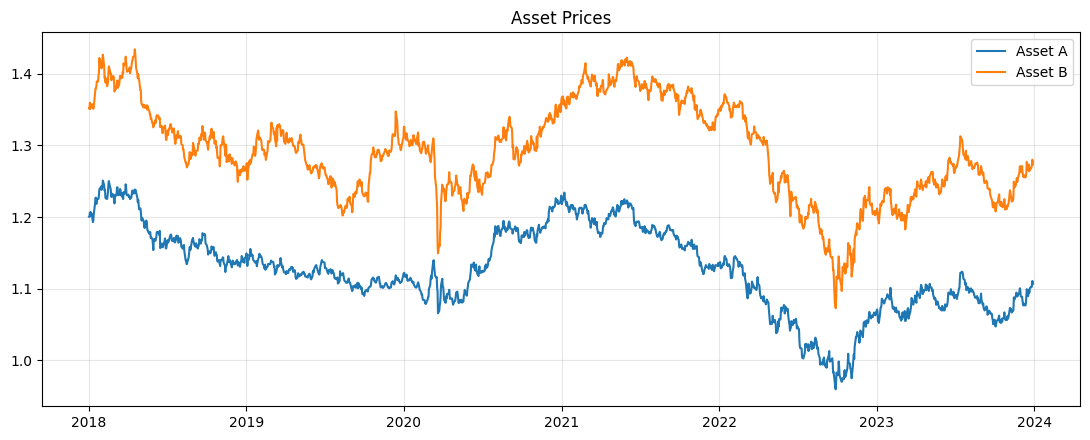

In [ ]:
fig, ax = plt.subplots()
ax.plot(prices.index, prices['A'], label='Asset A')
ax.plot(prices.index, prices['B'], label='Asset B')
ax.set_title('Asset Prices')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Cointegration Test & Hedge Ratio Estimation

Engle-Granger two-step approach:
1. OLS regress `log(A)` on `log(B)` to get the hedge ratio γ.
2. Run an ADF test on the regression residuals (the spread). Stationary residuals ⇒ cointegration.

We also run `statsmodels`' built-in `coint()` test (Engle-Granger with proper critical values)
as a cross-check, and compute the half-life of mean reversion.


In [ ]:
def estimate_hedge_ratio(log_a: pd.Series, log_b: pd.Series):
    X = sm.add_constant(log_b)
    model = sm.OLS(log_a, X).fit()
    alpha, gamma = model.params.iloc[0], model.params.iloc[1]
    spread = log_a - (alpha + gamma * log_b)
    return gamma, alpha, spread


def test_cointegration(log_a: pd.Series, log_b: pd.Series):
    gamma, alpha, spread = estimate_hedge_ratio(log_a, log_b)

    adf_stat, adf_pvalue, *_ = adfuller(spread, autolag='AIC')
    eg_stat, eg_pvalue, _ = coint(log_a, log_b)

    return {
        'gamma': gamma, 'alpha': alpha, 'spread': spread,
        'adf_stat': adf_stat, 'adf_pvalue': adf_pvalue,
        'eg_stat': eg_stat, 'eg_pvalue': eg_pvalue,
    }


def compute_half_life(spread: pd.Series):
    spread_lag = spread.shift(1).dropna()
    spread_diff = spread.diff().dropna()
    spread_lag = spread_lag.loc[spread_diff.index]

    X = sm.add_constant(spread_lag)
    model = sm.OLS(spread_diff, X).fit()
    lam = model.params.iloc[1]
    if lam >= 0:
        return np.inf   # not mean reverting
    half_life = -np.log(2) / lam
    return half_life


def hurst_exponent(series: pd.Series, max_lag=50):
    lags = range(2, max_lag)
    tau = [np.std(np.subtract(series.values[lag:], series.values[:-lag])) for lag in lags]
    poly = np.polyfit(np.log(list(lags)), np.log(tau), 1)
    return poly[0] * 2.0


log_a_full = np.log(prices['A'])
log_b_full = np.log(prices['B'])

result = test_cointegration(log_a_full, log_b_full)
half_life = compute_half_life(result['spread'])
hurst = hurst_exponent(result['spread'])

print(f"Hedge ratio (gamma):        {result['gamma']:.4f}")
print(f"ADF stat / p-value:         {result['adf_stat']:.3f} / {result['adf_pvalue']:.4f}")
print(f"Engle-Granger stat / p-val: {result['eg_stat']:.3f} / {result['eg_pvalue']:.4f}")
print(f"Half-life (bars):           {half_life:.1f}")
print(f"Hurst exponent:             {hurst:.3f}  (< 0.5 suggests mean reversion)")

is_valid_pair = (
    result['adf_pvalue'] < CFG.adf_pvalue_max
    and CFG.min_half_life <= half_life <= CFG.max_half_life
    and hurst < 0.5
)
print(f"\nPair passes validation checklist: {is_valid_pair}")

# half_life above is in BARS at the current interval; convert to calendar days for the guide
half_life_days = half_life / bars_per_day(CFG.interval)
print()
recommend_timeframe(half_life_days)


Hedge ratio (gamma):        0.9094
ADF stat / p-value:         -3.347 / 0.0129
Engle-Granger stat / p-val: -3.348 / 0.0484
Half-life (bars):           45.5
Hurst exponent:             0.809  (< 0.5 suggests mean reversion)

Pair passes validation checklist: False

Estimated half-life: 45.5 days

-> Half-life is long (multiple weeks+). Use interval='1d' (or even '1wk').
   Intraday bars would need an unrealistically long formation window relative to
   yfinance's history limits to see even a handful of full reversion cycles.

Rule of thumb: you generally want (available history in days) / (half-life in days)
to be at least ~10-15, so the backtest actually observes multiple reversion cycles
rather than just a couple of noisy ones.


## 4. Ornstein-Uhlenbeck Model Fit

Fit `dr(t) = -θ(r(t) − μ)dt + σ dW(t)` to the spread via discretized maximum likelihood
(equivalent to the AR(1) regression above, but framed with explicit μ, θ, σ and the
stationary-distribution z-score described in the write-up).


In [ ]:
def fit_ou_mle(spread: pd.Series, dt=1.0):
    x = spread.values
    x_lag, x_t = x[:-1], x[1:]

    def neg_log_likelihood(params):
        mu, theta, sigma = params
        if theta <= 0 or sigma <= 0:
            return 1e10
        mean = x_lag + theta * (mu - x_lag) * dt
        var = sigma**2 * dt
        ll = -0.5 * np.log(2 * np.pi * var) - (x_t - mean)**2 / (2 * var)
        return -np.sum(ll)

    x0 = [np.mean(x), 0.1, np.std(np.diff(x))]
    res = minimize(neg_log_likelihood, x0, method='Nelder-Mead')
    mu_hat, theta_hat, sigma_hat = res.x
    return mu_hat, theta_hat, sigma_hat


mu_hat, theta_hat, sigma_hat = fit_ou_mle(result['spread'])
sigma_eq = sigma_hat / np.sqrt(2 * theta_hat)
ou_half_life = np.log(2) / theta_hat

print(f"OU mu (equilibrium mean):     {mu_hat:.5f}")
print(f"OU theta (reversion speed):   {theta_hat:.5f}")
print(f"OU sigma (volatility):        {sigma_hat:.5f}")
print(f"OU implied half-life:         {ou_half_life:.1f} bars")
print(f"Stationary std (sigma_eq):    {sigma_eq:.5f}")

if ground_truth:
    print(f"\n(Ground truth for comparison: gamma={ground_truth['gamma_true']}, "
          f"theta={ground_truth['theta_true']}, mu={ground_truth['mu_true']}, "
          f"sigma={ground_truth['sigma_true']})")


OU mu (equilibrium mean):     -0.00000
OU theta (reversion speed):   0.01525
OU sigma (volatility):        0.00404
OU implied half-life:         45.5 bars
Stationary std (sigma_eq):    0.02313


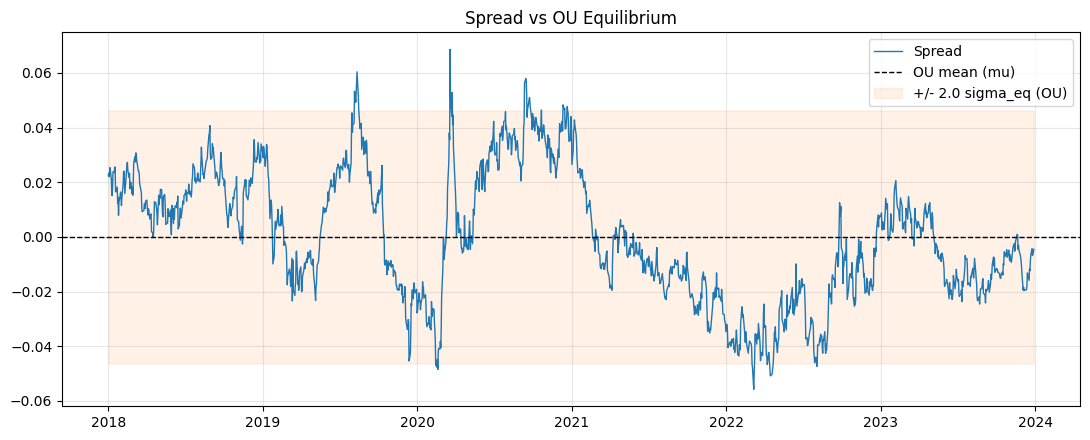

In [ ]:
z_ou = (result['spread'] - mu_hat) / sigma_eq

fig, ax = plt.subplots()
ax.plot(result['spread'].index, result['spread'], label='Spread', lw=1)
ax.axhline(mu_hat, color='black', ls='--', lw=1, label='OU mean (mu)')
ax.fill_between(result['spread'].index, mu_hat - CFG.z_entry * sigma_eq,
                 mu_hat + CFG.z_entry * sigma_eq, alpha=0.1, color='C1',
                 label=f'+/- {CFG.z_entry} sigma_eq (OU)')
ax.set_title('Spread vs OU Equilibrium')
ax.legend()
plt.tight_layout()
plt.show()


## 5. Signal Generation (rolling z-score)

The backtest below uses a **rolling sample z-score** (re-estimated at each formation date,
using only past data) rather than the single full-sample OU fit above, which is shown mainly
for illustration since it was fit on the whole series. The walk-forward loop in Section 7
avoids that look-ahead problem.


In [ ]:
def generate_signals(log_a: pd.Series, log_b: pd.Series, gamma: float,
                      z_window: int, z_entry: float, z_exit: float):
    spread = log_a - gamma * log_b
    roll_mean = spread.rolling(z_window).mean()
    roll_std = spread.rolling(z_window).std()
    z = (spread - roll_mean) / roll_std

    position = 0   # 0 = flat, 1 = long spread, -1 = short spread
    positions = []
    for zt in z:
        if pd.isna(zt):
            positions.append(0)
            continue
        if position == 0:
            if zt < -z_entry:
                position = 1
            elif zt > z_entry:
                position = -1
        else:
            if abs(zt) < z_exit:
                position = 0
        positions.append(position)

    sig = pd.DataFrame({'spread': spread, 'z': z, 'position': positions}, index=log_a.index)
    return sig


## 6. Walk-Forward Backtest Engine

At each formation date, the hedge ratio and cointegration validity are estimated using
**only data available up to that point**. Trading then proceeds forward using that frozen
hedge ratio until the next reformation date. Risk controls (max holding period, stop-loss,
rolling cointegration re-check, hedge-ratio drift) are evaluated bar-by-bar using only
information available at that bar — no look-ahead.


In [ ]:
def run_backtest(prices: pd.DataFrame, cfg: Config):
    log_a = np.log(prices['A'])
    log_b = np.log(prices['B'])
    n = len(prices)

    trades = []
    equity = [cfg.capital_per_trade]
    equity_dates = [prices.index[0]]

    position = 0          # 0 flat, 1 long-spread, -1 short-spread
    entry_idx = None
    entry_gamma = None

    t = cfg.formation_window
    while t < n - 1:
        # --- FORMATION: estimate gamma + validate using only data up to t ---
        hist_a = log_a.iloc[t - cfg.formation_window: t]
        hist_b = log_b.iloc[t - cfg.formation_window: t]
        info = test_cointegration(hist_a, hist_b)
        hl = compute_half_life(info['spread'])

        pair_valid = (
            info['adf_pvalue'] < cfg.adf_pvalue_max
            and cfg.min_half_life <= hl <= cfg.max_half_life
        )
        gamma = info['gamma']

        # --- TRADE forward until next reformation date (or run out of data) ---
        window_end = min(t + cfg.reform_frequency, n - 1)

        for i in range(t, window_end):
            if i < cfg.z_window:
                continue

            hist_window_a = log_a.iloc[i - cfg.z_window: i + 1]
            hist_window_b = log_b.iloc[i - cfg.z_window: i + 1]
            spread_hist = hist_window_a - gamma * hist_window_b
            z = (spread_hist.iloc[-1] - spread_hist.mean()) / spread_hist.std()

            if position == 0:
                if not pair_valid:
                    continue
                if z < -cfg.z_entry:
                    position, entry_idx, entry_gamma = 1, i, gamma
                elif z > cfg.z_entry:
                    position, entry_idx, entry_gamma = -1, i, gamma
            else:
                exit_reason = None
                holding = i - entry_idx

                if abs(z) < cfg.z_exit:
                    exit_reason = 'target'
                elif holding >= cfg.max_holding_period:
                    exit_reason = 'max_holding_period'
                elif abs(z) > cfg.stop_loss_z:
                    exit_reason = 'stop_loss'
                else:
                    # rolling cointegration re-check on recent data only
                    recent_a = log_a.iloc[max(0, i - cfg.formation_window): i + 1]
                    recent_b = log_b.iloc[max(0, i - cfg.formation_window): i + 1]
                    if len(recent_a) >= 60 and i % 10 == 0:  # check periodically, not every bar (cost)
                        recent_info = test_cointegration(recent_a, recent_b)
                        if recent_info['adf_pvalue'] > cfg.retest_pvalue_max:
                            exit_reason = 'cointegration_broken'
                        elif abs(recent_info['gamma'] - entry_gamma) / abs(entry_gamma) > cfg.gamma_drift_limit:
                            exit_reason = 'gamma_drift'

                if exit_reason:
                    r_a = (prices['A'].iloc[i] - prices['A'].iloc[entry_idx]) / prices['A'].iloc[entry_idx]
                    r_b = (prices['B'].iloc[i] - prices['B'].iloc[entry_idx]) / prices['B'].iloc[entry_idx]
                    gross = (r_a - entry_gamma * r_b) if position == 1 else (-r_a + entry_gamma * r_b)
                    cost = 4 * cfg.cost_bps_per_leg / 10000.0   # 2 legs in + 2 legs out
                    net = gross - cost

                    trades.append({
                        'entry_date': prices.index[entry_idx], 'exit_date': prices.index[i],
                        'direction': 'long_spread' if position == 1 else 'short_spread',
                        'gamma': entry_gamma, 'holding_period': holding,
                        'gross_return': gross, 'net_return': net, 'exit_reason': exit_reason,
                    })
                    equity.append(equity[-1] * (1 + net))
                    equity_dates.append(prices.index[i])
                    position, entry_idx, entry_gamma = 0, None, None

        t += cfg.reform_frequency

    equity_curve = pd.Series(equity, index=equity_dates)
    trades_df = pd.DataFrame(trades)
    return trades_df, equity_curve


trades_df, equity_curve = run_backtest(prices, CFG)
print(f"Number of trades: {len(trades_df)}")
trades_df.head(10)


Number of trades: 19


,entry_date,exit_date,direction,gamma,holding_period,gross_return,net_return,exit_reason
0,2019-01-16,2019-01-28,long_spread,0.8391,8,-0.0223,-0.0227,cointegration_broken
1,2019-02-27,2019-03-11,long_spread,0.8391,8,0.0030,0.0026,cointegration_broken
2,2019-03-12,2019-03-21,long_spread,0.8391,7,0.0177,0.0173,target
3,2019-11-08,2019-11-19,long_spread,0.2971,7,0.0008,0.0004,cointegration_broken
4,2020-06-02,2020-07-01,short_spread,0.1334,21,-0.0109,-0.0113,target
5,2020-07-15,2020-07-28,short_spread,0.1334,9,-0.0280,-0.0284,cointegration_broken
6,2020-07-29,2020-08-11,short_spread,0.1334,9,-0.0000,-0.0004,cointegration_broken
7,2021-02-24,2021-03-09,long_spread,0.9474,9,-0.0048,-0.0052,cointegration_broken
8,2021-04-01,2021-04-06,long_spread,0.9474,3,-0.0011,-0.0015,cointegration_broken
9,2022-03-10,2022-03-23,short_spread,1.3190,9,0.0121,0.0117,target


## 7. Performance Metrics

In [ ]:
def compute_performance(trades_df: pd.DataFrame, equity_curve: pd.Series, periods_per_year=252):
    if len(trades_df) == 0:
        print("No trades were generated - relax entry thresholds or check pair validity.")
        return {}

    total_return = equity_curve.iloc[-1] / equity_curve.iloc[0] - 1
    n_trades = len(trades_df)
    win_rate = (trades_df['net_return'] > 0).mean()
    avg_trade_return = trades_df['net_return'].mean()
    avg_holding = trades_df['holding_period'].mean()

    # approximate daily-equivalent returns from the (irregularly spaced) equity curve
    eq_returns = equity_curve.pct_change().dropna()
    avg_days_between = np.mean(np.diff(equity_curve.index).astype('timedelta64[D]').astype(float))
    periods_per_year_eff = 365.25 / avg_days_between if avg_days_between > 0 else periods_per_year

    sharpe = (eq_returns.mean() / eq_returns.std()) * np.sqrt(periods_per_year_eff) if eq_returns.std() > 0 else np.nan

    running_max = equity_curve.cummax()
    drawdown = (equity_curve - running_max) / running_max
    max_drawdown = drawdown.min()

    exit_reason_counts = trades_df['exit_reason'].value_counts()

    metrics = {
        'Total Return': f"{total_return:.2%}",
        'Number of Trades': n_trades,
        'Win Rate': f"{win_rate:.2%}",
        'Average Trade Return': f"{avg_trade_return:.3%}",
        'Average Holding Period (bars)': f"{avg_holding:.1f}",
        'Sharpe Ratio (annualized, approx)': f"{sharpe:.2f}",
        'Max Drawdown': f"{max_drawdown:.2%}",
    }

    print("=== Performance Summary ===")
    for k, v in metrics.items():
        print(f"{k:35s}: {v}")
    print("\n=== Exit Reasons ===")
    print(exit_reason_counts)

    return metrics


metrics = compute_performance(trades_df, equity_curve, CFG.periods_per_year)


=== Performance Summary ===
Total Return                       : 0.04%
Number of Trades                   : 19
Win Rate                           : 57.89%
Average Trade Return               : 0.010%
Average Holding Period (bars)      : 9.2
Sharpe Ratio (annualized, approx)  : 0.01
Max Drawdown                       : -4.89%

=== Exit Reasons ===
exit_reason
target                  11
cointegration_broken     8
Name: count, dtype: int64


**Note on the Sharpe/annualization figure above**: it's computed from the actual calendar
gaps between trade exits (`avg_days_between`), not from `CFG.periods_per_year` directly — the
resolved `periods_per_year` from `resolve_config()` is what you should use for interval-consistent
comparisons *between* runs at different timeframes (e.g. comparing a `1d` config against a `1h`
config), since the realized annualization above depends on how often trades actually closed.


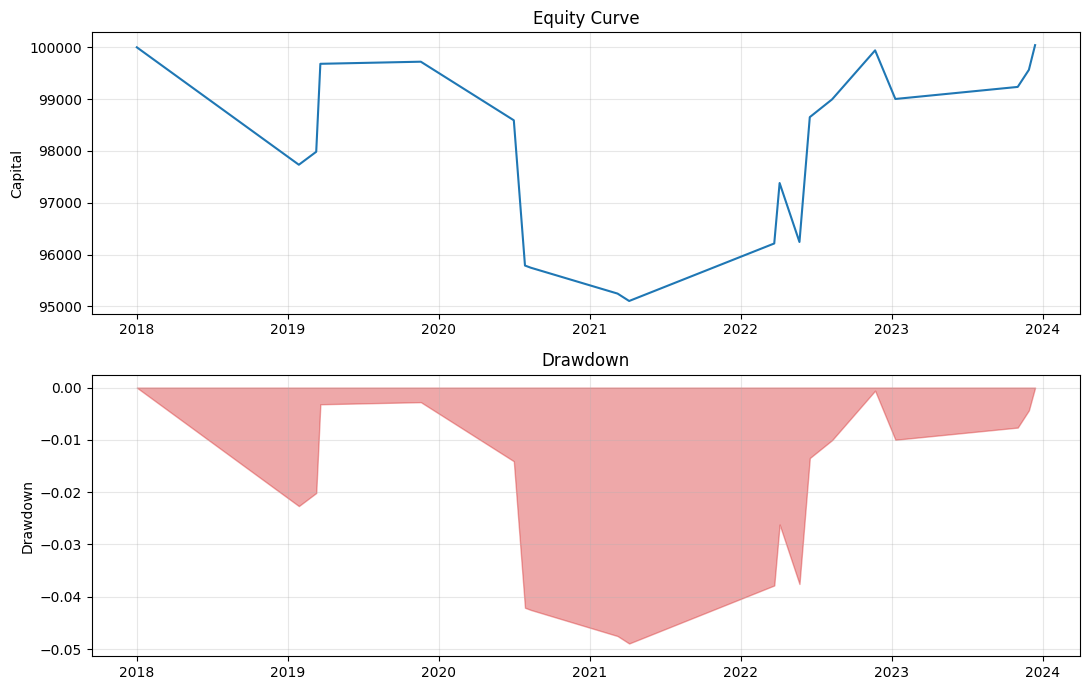

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

axes[0].plot(equity_curve.index, equity_curve.values)
axes[0].set_title('Equity Curve')
axes[0].set_ylabel('Capital')

running_max = equity_curve.cummax()
drawdown = (equity_curve - running_max) / running_max
axes[1].fill_between(drawdown.index, drawdown.values, 0, color='C3', alpha=0.4)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown')

plt.tight_layout()
plt.show()


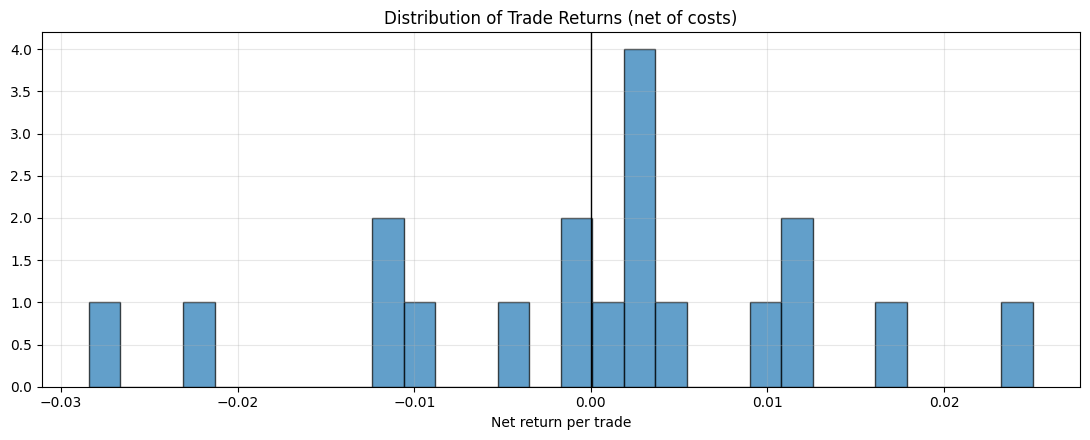

In [ ]:
if len(trades_df) > 0:
    fig, ax = plt.subplots()
    ax.hist(trades_df['net_return'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='black', lw=1)
    ax.set_title('Distribution of Trade Returns (net of costs)')
    ax.set_xlabel('Net return per trade')
    plt.tight_layout()
    plt.show()


## 8. Switching to Real Data, at Different Timeframes

### 8a. Basic switch

To run this on actual EUR/USD, GBP/USD, or other FX pairs on your own machine (this sandbox
has no network access to Yahoo Finance):

```python
CFG.data_source = "yfinance"
CFG.ticker_a = "EURUSD=X"
CFG.ticker_b = "GBPUSD=X"
CFG.interval = "1d"
CFG.start_date = "2015-01-01"
CFG.end_date = "2024-01-01"
CFG = resolve_config(CFG)                       # re-derive bar counts from the *_days fields
check_data_availability(CFG.interval, CFG.start_date, CFG.end_date)

prices = load_yfinance_pair(CFG.ticker_a, CFG.ticker_b, CFG.start_date, CFG.end_date, CFG.interval)
```

Then re-run from Section 3 onward. Everything downstream (cointegration test, OU fit, signal
generation, backtest, metrics) is agnostic to the data source or interval, because the
formation window, z-window, and holding period are all defined in calendar days and converted
to bar counts by `resolve_config()`.

### 8b. What changes across timeframes, and why

| Interval | Max history (yfinance) | Bars/day (FX, ~24h) | Good for |
|---|---|---|---|
| `1m` | 7 days | 1,440 | Not practical for this strategy — too little history to validate cointegration |
| `5m` / `15m` / `30m` | 60 days | 288 / 96 / 48 | Short half-life pairs only; expect noisy, less reliable cointegration estimates |
| `1h` (`60m`) | ~730 days (~2 yrs) | 24 | Half-life of a few days to ~2 weeks |
| `1d` | full history | 1 | Default and safest choice; half-life of 1-3+ weeks |
| `1wk` / `1mo` | full history | ~0.2 / ~0.05 | Very slow-reverting pairs, long-horizon macro relationships |

**Why this matters mechanically, not just conceptually:**
- `yfinance` **hard-caps** how much intraday history it returns (see table). Ask for 6 years of
  `1h` data and you'll silently get the last ~2 years — `check_data_availability()` above warns
  you about this before you burn time debugging a "short" backtest.
- A `formation_window_days=252` means literally 252 rows at `1d`, but ~6,048 rows at `1h` — the
  *bar count* your regression and ADF test actually see is very different even though the
  calendar-time lookback is the same. `resolve_config()` handles this conversion so you only set
  the day-based numbers once.
- **Annualization** (`periods_per_year`, used in the Sharpe calculation) must scale with bar
  frequency too — an hourly Sharpe using a daily annualization factor will be wildly wrong.
  `resolve_config()` sets this automatically per interval.

### 8c. How to pick a timeframe for a *specific* pair

Use `recommend_timeframe()` (called automatically in Section 3 above) as a starting point: fit
the half-life on daily data first (it's the interval with no history limit, so it's the cheapest,
most reliable first pass), then let the half-life estimate tell you whether finer bars are even
usable:

- **Half-life > ~20 days** → stick with `1d` (or `1wk`). Going intraday buys you nothing here and
  the extra noise from more frequent re-estimation can hurt more than help.
- **Half-life ~3-20 days** → `1d` is still the safe default; `1h` is workable *if* the ~2-year
  history cap still gives you roughly 10-15+ full reversion cycles (`730 / half_life_days`
  should comfortably clear ~10).
- **Half-life < ~3 days** → daily bars barely see a full cycle. Intraday (`1h`, `30m`, `15m`) is
  more appropriate, but you're now constrained to 60-730 days of history depending on interval —
  validate the cointegration/half-life estimate is stable across sub-windows of that shorter
  sample before trusting it, since a shorter sample gives noisier statistics generally.

### 8d. FX-specific notes

- Use `Close`, not `Adj Close` — FX has no dividends/splits to adjust for (unlike equities).
- FX trades ~24h across 5 days; weekend gaps in the index are expected and fine, but don't let a
  rolling window's *bar count* silently span a weekend gap as if it were the same elapsed time as
  a weekday bar when reasoning about half-life in real time units.
- Consider rate-differential/carry effects for longer holding periods — this notebook doesn't
  currently net out carry, so `max_holding_period_days` should stay short enough that carry drift
  isn't a material confound, or you should extend the return calculation to account for it.


## 9. Limitations (read before using this on live capital)

- **Cointegration is not permanent.** A structural break (policy shift, central bank divergence,
  de-pegging, M&A) can permanently break the relationship. The rolling re-test and gamma-drift
  checks in the backtest are attempts to detect this *after the fact* — they do not predict it.
- **Estimation risk.** γ, μ, θ, σ, and half-life are all sample estimates with uncertainty,
  especially over shorter formation windows.
- **Multiple testing.** If this pipeline is run across many candidate pairs, some will pass the
  cointegration filter by chance. Out-of-sample validation on data untouched by parameter tuning
  is essential before trusting a backtest.
- **Transaction costs and slippage** used here (`cost_bps_per_leg`) are a simplification — real
  costs vary with liquidity, size, and market conditions, and short-leg borrow costs are not
  modeled at all.
- **This backtest still has simplifications relative to live trading**: fills are assumed at the
  bar's price with a flat cost, not at a realistic next-bar open with slippage; position sizing
  is notionally dollar-neutral rather than volatility-adjusted; and periodic (every-10-bar)
  rather than continuous cointegration re-checks are used to limit computation, which introduces
  a small amount of lag in detecting a broken relationship.
- **No result here is a guarantee of future performance**, on synthetic or real data.
